In [ ]:
import pandas as pd

# Reload the uploaded file after code execution state reset
file_path = '/content/formatting_data (6).csv'
df = pd.read_csv(file_path)

# Display basic info and first few rows
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Columns: 136 entries, Name to Channel
dtypes: bool(3), float64(34), int64(39), object(60)
memory usage: 3.1+ MB


(None,
     Name                  Email Location  Zip Code  Age  Gender Language  \
 0  User1  user1363@mondelez.com   London     46880   39    Male  Chinese   
 1  User2     user2917@gmail.com  NewYork     14720   34    Male  Chinese   
 2  User3   user3136@outlook.com   Sydney     98108   40    Male   French   
 3  User4  user4911@mondelez.com  NewYork     13640   23  Female  Chinese   
 4  User5     user5953@gmail.com  Toronto     61759   33   Other   French   
 
    Loyalty Program Member Product Name      Purchase History  ...  Ad_Clicks  \
 0                       0   Dairy Milk  Dairy Milk (7 times)  ...          9   
 1                       1         Tang        Tang (8 times)  ...          9   
 2                       1      Mirinda     Mirinda (3 times)  ...          9   
 3                       1         Star      5 Star (3 times)  ...          9   
 4                       0        Halls       Halls (4 times)  ...          9   
 
    Impressions Coupon_Code_Usage  Produc

In [ ]:
import re

# Extract number of purchases from 'Purchase History' column
def extract_purchases(purchase_str):
    match = re.search(r'(\d+)\s+times', str(purchase_str))
    return int(match.group(1)) if match else 0

# Create a new column 'total_purchases'
df['total_purchases'] = df['Purchase History'].apply(extract_purchases)

# Calculate summary statistics
df['total_purchases'].describe()


,total_purchases
count,3000.000000
mean,1.793333
std,3.007929
min,0.000000
25%,0.000000
50%,0.000000
75%,3.000000
max,10.000000


 CLV Estimation using Pareto/NBD Model

In [ ]:
# Step 0: Install lifetimes package
!pip install lifetimes --quiet

# Step 1: Imports
import pandas as pd
import numpy as np
from lifetimes import BetaGeoFitter
from lifetimes.utils import summary_data_from_transaction_data
import matplotlib.pyplot as plt

# Step 2: Load and clean the data
df = pd.read_csv('/content/formatting_data (6).csv')
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

# Step 3: Simulate transaction data
np.random.seed(42)
simulated_txns = []

for cust in df['customer_id'].unique():
    num_txns = df.loc[df['customer_id'] == cust, 'total_completed_purchase_value'].values[0]
    txn_months = np.sort(np.random.choice(range(1, 11), size=min(int(num_txns), 10), replace=False))
    for month in txn_months:
        simulated_txns.append([cust, f"2023-{month:02d}-15"])

simulated_txn_df = pd.DataFrame(simulated_txns, columns=['customer_id', 'date'])
simulated_txn_df['date'] = pd.to_datetime(simulated_txn_df['date'])

# Step 4: Prepare summary data
summary = summary_data_from_transaction_data(
    simulated_txn_df,
    customer_id_col='customer_id',
    datetime_col='date',
    observation_period_end='2023-10-31'
)

# Step 5: Fit Pareto/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

# Step 6: Predict future purchases
summary['pred_30m_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30, summary['frequency'], summary['recency'], summary['T']
)
summary['pred_50m_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    50, summary['frequency'], summary['recency'], summary['T']
)

# Step 7: Estimate Customer Lifetime Value
avg_order_value = 500
summary['clv_30m'] = summary['pred_30m_purchases'] * avg_order_value
summary['clv_50m'] = summary['pred_50m_purchases'] * avg_order_value

# Step 8: Output results
summary[['pred_30m_purchases', 'pred_50m_purchases', 'clv_30m', 'clv_50m']].head()


,pred_30m_purchases,pred_50m_purchases,clv_30m,clv_50m
customer_id,,,,
1002,0.930296,1.550494,465.148108,775.246847
1018,0.930296,1.550494,465.148108,775.246847
1049,0.930296,1.550494,465.148108,775.246847
1052,0.930296,1.550494,465.148108,775.246847
1053,0.930296,1.550494,465.148108,775.246847


visualizations or CLV segmentation

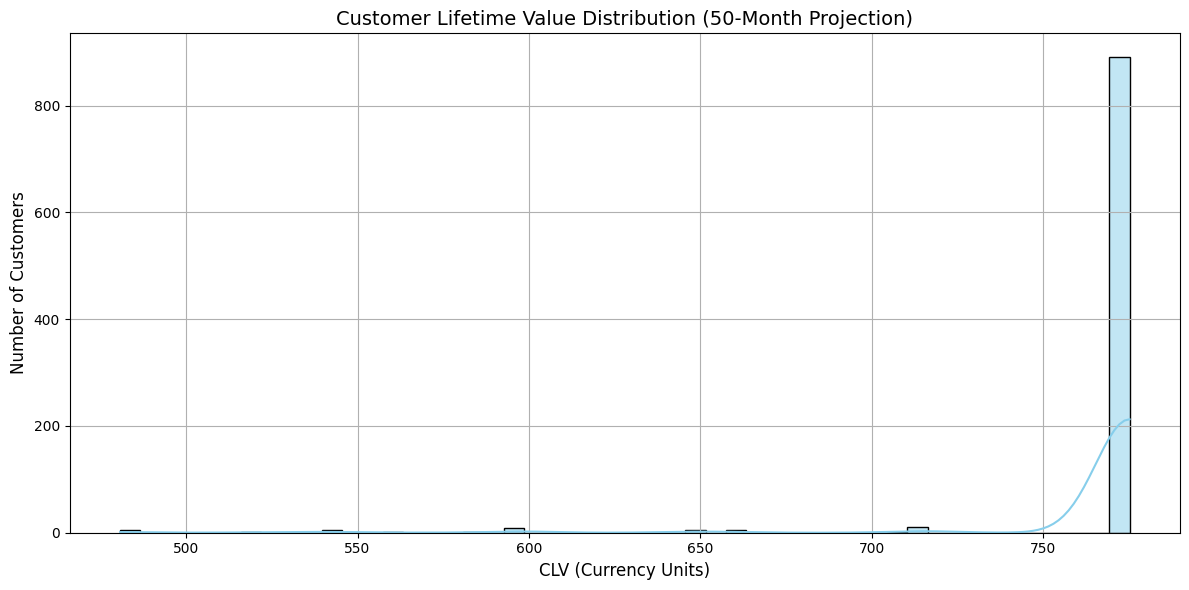

                clv_30m     clv_50m
customer_id                        
1002         465.148108  775.246847
1018         465.148108  775.246847
1049         465.148108  775.246847
1052         465.148108  775.246847
1053         465.148108  775.246847


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize distribution of CLV (50-month projection)
plt.figure(figsize=(12, 6))
sns.histplot(summary['clv_50m'], bins=50, kde=True, color='skyblue')
plt.title('Customer Lifetime Value Distribution (50-Month Projection)', fontsize=14)
plt.xlabel('CLV (Currency Units)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Segment top 10% high CLV customers
threshold = summary['clv_50m'].quantile(0.90)
high_clv_customers = summary[summary['clv_50m'] >= threshold]

# Show top high CLV customers
print(high_clv_customers[['clv_30m', 'clv_50m']].head())


Survival Analysis

1. Ready data for Survival Analysis add 'duration' in data

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv('/content/formatting_data (6).csv')
current_date = pd.to_datetime('2025-05-23')

# Convert date columns to datetime objects
data['First Interaction Date'] = pd.to_datetime(data['First Interaction Date'])
data['Last Purchase Date'] = pd.to_datetime(data['Last Purchase Date'])

data['Churn_Risk'] = data['Churn_Risk'].replace(['High'], 1).replace(['Low'], 0)

# Calculate 'duration' using np.where for row-wise conditional logic
data['duration'] = np.where(
    data['Churn_Risk'] == 1,  # Condition: if Churn_Risk is 1
    data['Last Purchase Date'] - data['First Interaction Date'], # Value if True
    current_date - data['First Interaction Date'] # Value if False
)
data['duration'] = data['duration'].dt.days
data['duration'] = data['duration'].abs()
data.to_csv("survival_analysis_input.csv")

# Now 'duration' column is calculated based on the 'Churn_Risk' for each row
print(data[['Churn_Risk', 'First Interaction Date', 'Last Purchase Date', 'duration']].head())

   Churn_Risk First Interaction Date Last Purchase Date  duration
0           0             2021-03-10         2024-12-07      1535
1           0             2022-04-24         2024-09-10      1125
2           0             2022-01-08         2025-01-22      1231
3           0             2022-01-16         2024-09-08      1223
4           0             2021-12-14         2024-08-18      1256


In [ ]:
pip install lifelines

 2. Kalpan-Meier Survival Analysis (by Top CLTV)

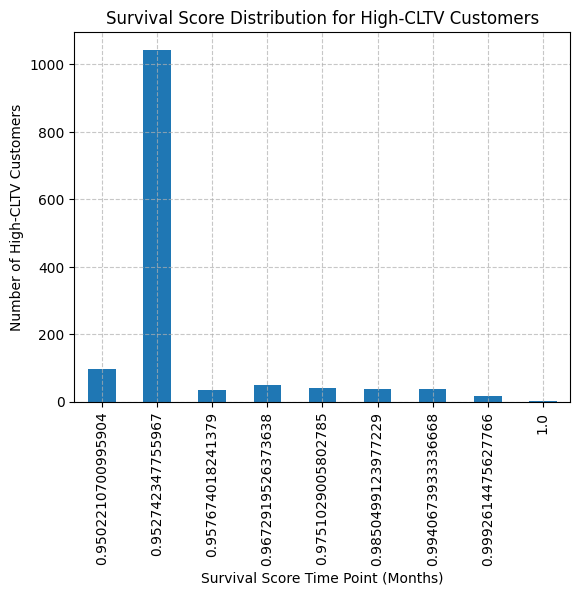

      duration  Churn_Risk  survival_score
0         1535           0        0.950221
1         1125           0        0.950221
2         1231           0        0.950221
3         1223           0        0.950221
4         1256           0        0.950221
...        ...         ...             ...
2995       122           0        1.000000
2996       123           0        1.000000
2997       221           1        0.999261
2998       125           0        1.000000
2999       126           0        1.000000

[3000 rows x 3 columns]
Survival Probabilities at 3-month intervals (in months):
0     1.000000
3     1.000000
6     0.999261
9     0.994067
12    0.985050
15    0.975103
18    0.967292
21    0.957674
24    0.952742
27    0.950221
30    0.950221
33    0.950221
36    0.950221
39    0.950221
42    0.950221
45    0.950221
48    0.950221
51    0.950221
54    0.950221
57    0.950221
dtype: float64

Distribution of Survival Scores (Number of High-CLTV Customers):
survival_score
0.9502

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Load dataset
data = pd.read_csv("/content/survival_analysis_input.csv")

# Step 1: Calculate CLTV
data['lifespan_years'] = data['duration'] / 365
data['CLTV'] = data['Avg Order Value'] * data['Purchase_Frequency'] * data['lifespan_years']

# Step 2: Filter high-CLTV customers
cltv_threshold = data['CLTV'].quantile(0.75)  # Top 25%
high_cltv_data = data[data['CLTV'] >= cltv_threshold].copy()

# Step 3: Convert duration to months
high_cltv_data['duration_months'] = high_cltv_data['duration'] / 30

# Step 4: Determine maximum duration in months
max_duration_months = high_cltv_data['duration_months'].max()
max_duration_months = int(np.ceil(max_duration_months))

# Step 5: Create 3-month intervals
specific_months = list(range(0, max_duration_months + 3, 3))  # 0, 3, 6, 9, ...
specific_days = [month * 30 for month in specific_months]  # 90, 180, 270, ...

# Step 6: Fit Kaplan-Meier model
kmf = KaplanMeierFitter()
kmf.fit(high_cltv_data['duration'], event_observed=high_cltv_data['Churn_Risk'])

# Step 7: Get survival probabilities
survival_probs = kmf.survival_function_at_times(specific_days).to_dict()
survival_probs_months = {month: prob for month, prob in zip(specific_months, survival_probs.values())}

# Step 8: Assign survival scores
def assign_survival_score(duration_days, specific_days, survival_probs):
    closest_day = max([d for d in specific_days if d <= duration_days], default=specific_days[0])
    return survival_probs[closest_day]

high_cltv_data['survival_score'] = high_cltv_data['duration'].apply(
    lambda x: assign_survival_score(x, specific_days, survival_probs)
)

# Step 9: Compute distribution
score_distribution = high_cltv_data['survival_score'].value_counts().sort_index()

score_distribution.plot(kind='bar')
plt.xlabel("Survival Score Time Point (Months)")
plt.ylabel("Number of High-CLTV Customers")
plt.title("Survival Score Distribution for High-CLTV Customers")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# Step 10: Print results
# Add survival score to each customer
data['survival_score'] = data['duration'].apply(lambda x: assign_survival_score(x, specific_days, survival_probs))
print(data[['duration', 'Churn_Risk', 'survival_score']])

print("Survival Probabilities at 3-month intervals (in months):")
print(pd.Series(survival_probs_months))
print("\nDistribution of Survival Scores (Number of High-CLTV Customers):")
print(score_distribution)
print(f"\nNumber of high-CLTV customers (CLTV >= {cltv_threshold}): {len(high_cltv_data)}")
print(f"Maximum duration: {max_duration_months} months")

 1. Export High CLV Customers for Retargeting


In [ ]:
# Save top 10% high CLV customers to CSV
high_clv_customers.to_csv('high_clv_customers.csv', index=True)


2. Combine with Churn Risk (if available)

In [ ]:
# Assume churn_risk column exists in original df and can be merged on customer_id
combined_df = high_clv_customers.merge(df[['customer_id', 'churn_risk']], on='customer_id', how='left')

# Filter only customers at high risk of churn
retargeting_list = combined_df[combined_df['churn_risk'] == 'High']

# Export retargeting list
retargeting_list.to_csv('retarget_high_clv_churn_risk.csv', index=False)


Retargeting High CLV + High Churn Risk Customers

1. Merge CLV with Churn Risk

In [ ]:
# Merge high CLV customer predictions with original churn data
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
combined_df = high_clv_customers.merge(df[['customer_id', 'churn_risk']], on='customer_id', how='left')


2. Filter for High Churn Risk Customers

In [ ]:
# Filter high CLV customers who are also at high risk of churn
retargeting_list = combined_df[combined_df['churn_risk'].str.lower() == 'high']


3. Export Retargeting List

In [ ]:
# Export final list for marketing/CRM team
retargeting_list.to_csv('retarget_high_clv_churn_risk.csv', index=False)
print("Retargeting list exported: retarget_high_clv_churn_risk.csv")


Retargeting list exported: retarget_high_clv_churn_risk.csv


4. Visualization

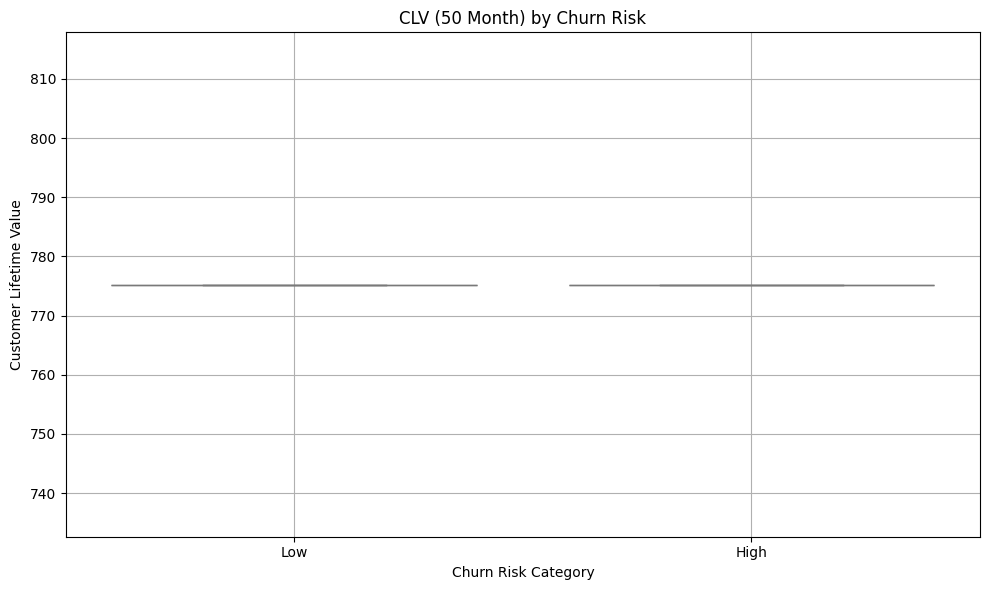

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# CLV distribution by churn risk
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_df, x='churn_risk', y='clv_50m', palette='coolwarm')
plt.title('CLV (50 Month) by Churn Risk')
plt.ylabel('Customer Lifetime Value')
plt.xlabel('Churn Risk Category')
plt.grid(True)
plt.tight_layout()
plt.show()


boxplot visualization that visually confirms that high churn risk customers can still be highly valuable




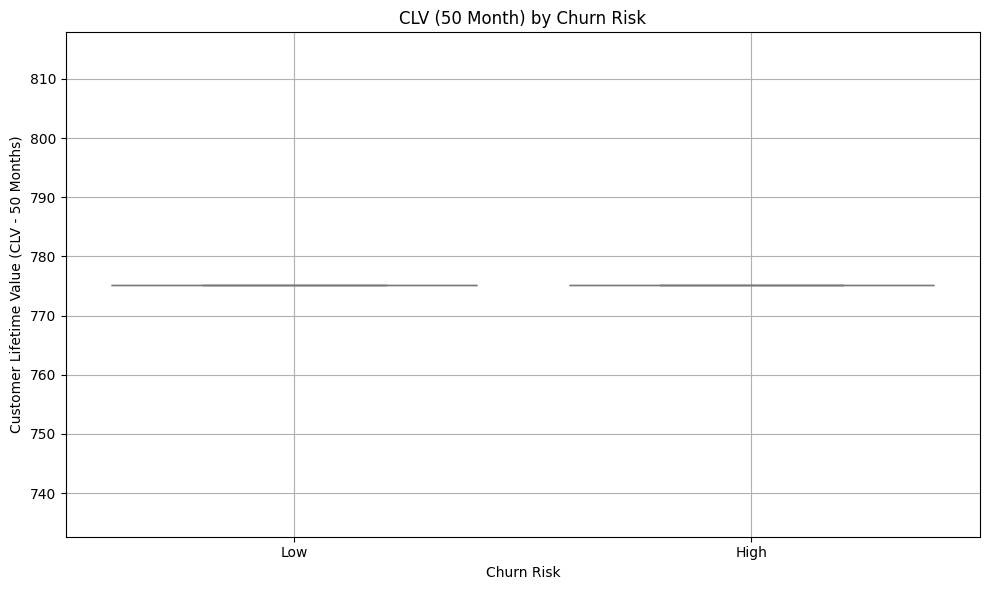

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your high CLV customers data and original dataset (for churn risk)
high_clv_customers = pd.read_csv('high_clv_customers.csv')
df = pd.read_csv('formatting_data (6).csv')

# Clean column names
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

# Merge the two datasets on customer_id to combine CLV (50m) and churn risk info
combined_df = high_clv_customers.merge(df[['customer_id', 'churn_risk']], on='customer_id', how='left')

# Create a boxplot to visualize CLV (50-month projection) by churn risk category
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_df, x='churn_risk', y='clv_50m', palette='coolwarm')
plt.title('CLV (50 Month) by Churn Risk')
plt.xlabel('Churn Risk')
plt.ylabel('Customer Lifetime Value (CLV - 50 Months)')
plt.grid(True)
plt.tight_layout()
plt.show()
